In [1]:
import pandas as pd
import numpy as np

import sys
import os

sys.path.append(os.path.abspath("../src"))

from ebe import Population
import search_space
import data_preprocessing as dp

In [2]:
DATA_ID = 54
SEED = 13

In [3]:
# Load Data
X_train, y_train, X_val, y_val, X_test, y_test = dp.get_preprocessed_data(
        dataset_id=DATA_ID,
        scaling=True,
        random_seed=SEED,
        return_as='tensor',
        task_type='classification',
        categorical_strategy='label', 
        verbose=True
    )

input_size, output_size = dp.get_tensor_sizes(X_train, y_train)

Loading Dataset: vehicle


In [4]:

s_space = search_space.SearchSpace(input_size=input_size, 
                                       output_size=output_size)

In [5]:
import json
starting_path = '../experiments/ebe_vs/v2'
naml_path = os.path.join(starting_path,'naml')
with open(os.path.join(naml_path, f'{DATA_ID}_{SEED}_NAML.json')) as f:
    naml_results = json.load(f)
    naml_time_taken = naml_results["time_taken"]
    naml_max_test_acc = naml_results["test_accuracy_best_non_nn_model"]


with open(os.path.join(starting_path, f'standard/{DATA_ID}_{SEED}_ML.json')) as f:
    standard_results = json.load(f)
    ml_time_taken = standard_results["hist_gradient_boosting_training_time_sec"]
    ml_max_test_acc = standard_results["best_accuracy"]


max_metric = max(naml_max_test_acc, ml_max_test_acc)


In [6]:
naml_max_test_acc

0.8411764705882353

In [ ]:
BUDGET_FACTOR = 3
N_INDIVIDUALS = 100
starting_instances = int(0.3 * len(X_train))

time_budget_ebe = max(ml_time_taken * BUDGET_FACTOR, 15)
# percentile_drop = 25
baseline_metric = max_metric
population = Population(s_space, 
                            size=N_INDIVIDUALS,
                            starting_instances=starting_instances,
                            seed=SEED)

ebe_results_final = population.run_ebe(
                            X_train, y_train, X_val, y_val,
                            baseline_metric=baseline_metric,
                            max_generations=150,
                            time_budget=time_budget_ebe,
                            base_drop=0.2,
                            max_drop=0.3,
                            track_all_models=False)
ebe_results_final.head(10)


=== Generation 1 ===
[Prune] total=100, protected=96, hopeless=2, dropped=2, kept=98

=== Generation 2 ===
[Prune] total=100, protected=80, hopeless=12, dropped=12, kept=88

=== Generation 3 ===
[Prune] total=100, protected=75, hopeless=11, dropped=11, kept=89
[EBE] At gen 3, decision flipped: Worth training NN
EBE process completed.
[Post-EBE Extended Training] Launching extended training
Candidate 93 surpassed baseline (0.846 >= 0.841)


,id,batch_size,n_instances,epochs_trained,batches_trained,efforts,cumulative_times,arch_hidden_layers,arch_shape,arch_depth,...,p_above_goal,last_train_acc,last_train_loss,last_val_acc,last_val_loss,total_epoch_time,avg_epoch_time,forecast_horizon_time,forecast_CI_low,forecast_CI_high
62,84,64,"[162, 226, 316, 442]",3,12,"[0.0009992122650146484, 0.002000093460083008, ...","[0.0009992122650146484, 0.0029993057250976562,...","[91, 36, 33, 12]",pyramid,4,...,0.553959,0.650000,0.949412,0.632353,0.902169,0.032999,0.005500,0.106536,0.255162,1.000000
70,93,128,"[162, 226, 316, 442]",3,2816,"[0.0029997825622558594, 0.001999378204345703, ...","[0.0029997825622558594, 0.0049991607666015625,...","[68, 68, 68, 68, 68, 68, 68, 68]",constant,8,...,0.533383,1.000000,0.002013,0.845588,0.900235,0.043057,0.007176,5.156519,0.000000,1.000000
61,83,32,"[162, 226, 316, 442]",3,24,"[0.0010006427764892578, 0.0009996891021728516,...","[0.0010006427764892578, 0.0020003318786621094,...","[40, 50, 92]",inv_pyramid,3,...,0.456348,0.357143,1.789835,0.433824,1.230513,0.083375,0.013896,0.401597,0.395007,1.000000
20,29,128,"[162, 226, 316, 442]",3,7,"[0.0019989013671875, 0.0010001659393310547, 0....","[0.0019989013671875, 0.0029990673065185547, 0....","[39, 32, 17]",pyramid,3,...,0.451030,0.383333,1.345877,0.448529,1.187502,0.020004,0.003334,0.055117,0.000000,1.000000
49,66,128,"[162, 226, 316, 442]",3,7,"[0.0009992122650146484, 0.0009987354278564453,...","[0.0009992122650146484, 0.0019979476928710938,...","[63, 63]",constant,2,...,0.414195,0.316667,1.355017,0.352941,1.348976,0.015988,0.002665,0.052969,0.000000,1.000000
53,72,64,"[162, 226, 316, 442]",3,12,"[0.0025031566619873047, 0.0019998550415039062,...","[0.0025031566619873047, 0.004503011703491211, ...","[90, 36, 59, 31, 51, 62, 49, 92]",irregular,8,...,0.411665,0.350000,1.298988,0.294118,1.593539,0.044027,0.007338,0.202000,0.096040,1.000000
43,58,64,"[162, 226, 316, 442]",3,12,"[0.0010006427764892578, 0.0010027885437011719,...","[0.0010006427764892578, 0.0020034313201904297,...","[69, 69]",constant,2,...,0.397948,0.250000,1.380721,0.308824,1.356816,0.029998,0.005000,0.105025,0.000000,1.000000
81,107,32,"[162, 226]",1,6,"[0.0030012130737304688, 0.0030624866485595703,...","[0.0030012130737304688, 0.006063699722290039, ...","[98, 94, 68, 66, 59, 45, 38, 37, 28, 27, 19, 18]",pyramid,12,...,0.390383,0.000000,1.151707,0.279412,1.390445,0.042125,0.021063,0.321145,0.000000,1.000000
66,89,128,"[162, 226, 316, 442]",3,7,"[0.005575656890869141, 0.004603385925292969, 0...","[0.005575656890869141, 0.01017904281616211, 0....","[72, 72, 72, 72, 72, 72, 72, 72, 72, 72, 72, 7...",constant,21,...,0.384647,0.250000,1.437692,0.345588,1.323322,0.086371,0.014395,0.313230,0.092235,0.976275
57,77,128,"[162, 226, 316, 442]",3,7,"[0.0019996166229248047, 0.0020036697387695312,...","[0.0019996166229248047, 0.004003286361694336, ...","[97, 79, 23, 3, 23, 79, 97]",hourglass,6,...,0.381136,0.216667,6.075837,0.235294,2.925594,0.038015,0.006336,0.153998,0.000000,1.000000


In [8]:
# Train by ES the best model
population.final_decision()

{'ShouldYouEvenNN?': True,
 'Exp. Utility': 0.0002863874896840632,
 'p_above_goal': 0.5539593811591873,
 'benefit': 0.0730130709321043,
 'cost': 0.09003639221191406}

In [9]:
fidelity_ledger = population.fidelity_training(X_train, y_train, X_val, y_val)
fidelity_ledger.head()

Training top by ES (fidelity check)

[DEBUG] fidelity_val_acc types:
fidelity_val_acc
<class 'float'>    89
Name: count, dtype: int64
     id  fidelity_val_acc
0    93          0.830882
1    84          0.757353
2    29          0.676471
3    66          0.397059
4    83          0.750000
..  ...               ...
84   78               NaN
85  103               NaN
86   65               NaN
87  113               NaN
88   46               NaN

[89 rows x 2 columns]


,id,forecasted_val_acc,forecasted_CI_high,forecasted_CI_low,forecasted_at,forecast_horizon_time,fidelity_val_acc,fidelity_train_acc,fidelity_val_loss,learning_curve
0,93,0.939947,1.0,0.000000,5.178405,5.156519,0.830882,1.0,0.681328,"{'es_train_losses': [1.4453961849212646, 1.317..."
5,72,0.623400,1.0,0.096040,0.022013,0.202000,0.816176,0.890625,0.456562,"{'es_train_losses': [1.4101554155349731, 1.159..."
1,84,0.914190,1.0,0.255162,0.016500,0.106536,0.757353,0.571429,0.511416,"{'es_train_losses': [1.396759271621704, 1.3613..."
8,58,0.493993,1.0,0.000000,0.014999,0.105025,0.750000,0.765625,0.531763,"{'es_train_losses': [1.3552111387252808, 1.293..."
4,83,0.725924,1.0,0.395007,0.041688,0.401597,0.750000,0.6875,0.460941,"{'es_train_losses': [1.370889663696289, 1.3742..."


In [14]:
display(ebe_results_final.iloc[1].T)

id                                                                           93
batch_size                                                                  128
n_instances                                                [162, 226, 316, 442]
epochs_trained                                                                3
batches_trained                                                            2816
efforts                       [0.0029997825622558594, 0.001999378204345703, ...
cumulative_times              [0.0029997825622558594, 0.0049991607666015625,...
arch_hidden_layers                             [68, 68, 68, 68, 68, 68, 68, 68]
arch_shape                                                             constant
arch_depth                                                                    8
arch_activation_fn                   <class 'torch.nn.modules.activation.Tanh'>
arch_dropout_rate                                                           0.1
arch_optimizer_type                     

In [18]:
ebe_id

np.int64(84)

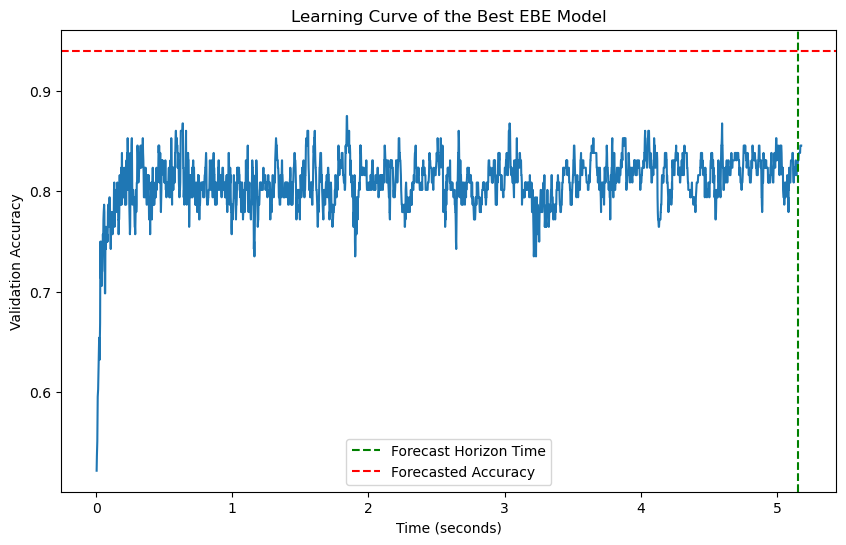

In [19]:
# plot the lc of the best model 
row = ebe_results_final.iloc[1]
ebe_id = row['id']

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.lineplot(x=row['cumulative_times'], y=row['val_acc'])
plt.title('Learning Curve of the Best EBE Model')
plt.xlabel('Time (seconds)')
plt.ylabel('Validation Accuracy')
plt.axvline(x=row["forecast_horizon_time"], color='g', linestyle='--', label='Forecast Horizon Time')

forecast = row['forecasted_val_acc']
plt.axhline(y=forecast, color='r', linestyle='--', label='Forecasted Accuracy')
plt.legend()

Forecast fidelity report:
  MAE : 0.16691706467984108
  Bias: 0.03513956110565707
     id  forecasted_val_acc  fidelity_val_acc     delta
42   43            0.320016          0.654412  0.334395
37   95            0.357002          0.683824  0.326822
29   47            0.393912          0.705882  0.311971
19   77            0.445844          0.742647  0.296803
78   39            0.286344          0.558824  0.272480
8    58            0.493993          0.750000  0.256007
10   37            0.469196          0.720588  0.251392
5    72            0.623400          0.816176  0.192777
6    89            0.534255          0.676471  0.142216
38   16            0.353818          0.470588  0.116770
4    83            0.725924          0.750000  0.024076
9    22            0.469454          0.426471 -0.042984
75   40            0.297099          0.250000 -0.047099
43   45            0.315538          0.264706 -0.050833
44   79            0.315346          0.257353 -0.057993
14  107            0.4

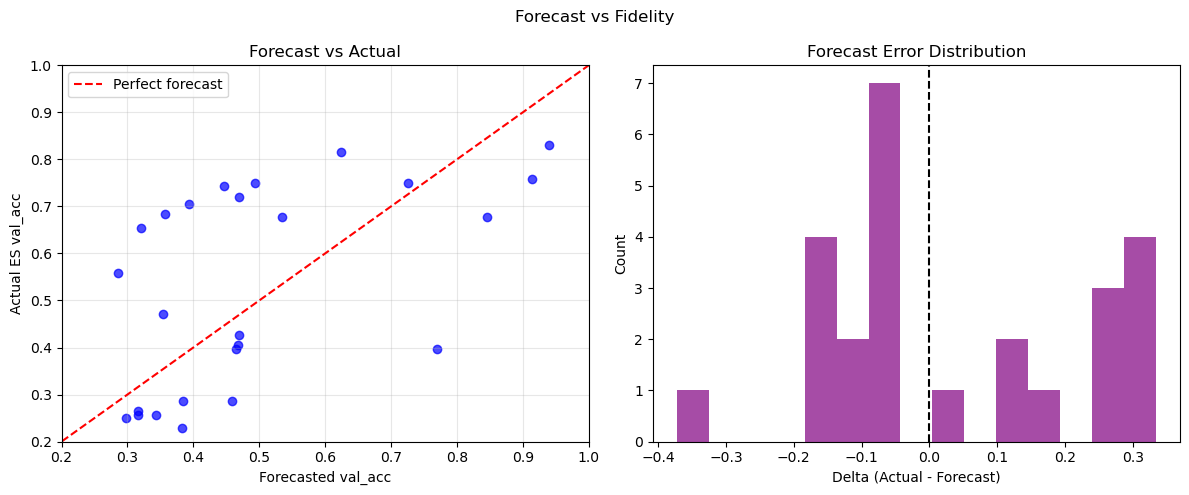

In [20]:
# fidelity_ledger = population.fidelity_ledger
report = population.compare_forecast_vs_fidelity()

print("Forecast fidelity report:")
print("  MAE :", report["MAE"])
print("  Bias:", report["Bias"])
print(report["details"])

from utils_viz import plot_forecast_vs_fidelity
plot_forecast_vs_fidelity(report, title="Forecast vs Fidelity")


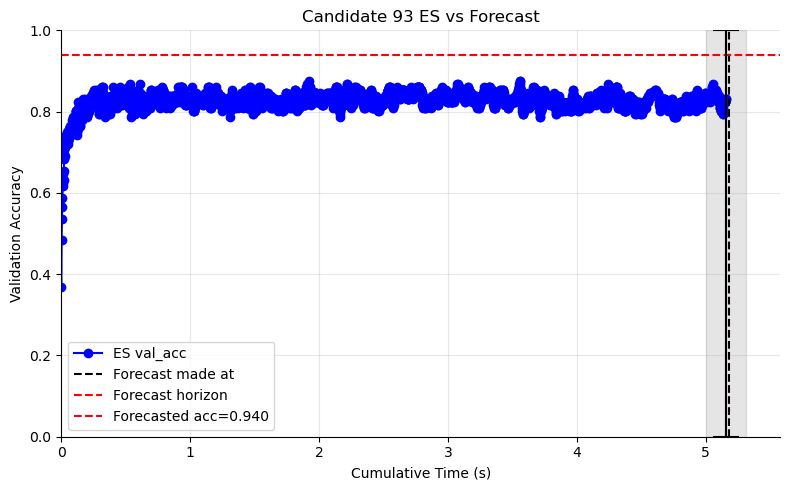

In [21]:
from utils_viz import plot_es_learning_curve_from_ledger
cand_id = ebe_id
row = fidelity_ledger[fidelity_ledger["id"] == cand_id].iloc[0]
plot_es_learning_curve_from_ledger(row)
